In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors


import os


import seaborn as sns


# For venn diagram
from matplotlib_venn import venn3, venn2
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm, cost_based


## Load RNA cell Barcodes from RNA-only modality CR analysis

In [81]:
# Save dataframe 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_RNA_cluster_and_DNAdebrisflag.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info.head(2)


,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris
atac_bc,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO


In [3]:
entropy_file = os.path.join(entropy_dir, 'calculated_barcode_entropy_wDNAdebrisflag_df.tsv')
entropy_df = pd.read_csv(entropy_file, sep=',', index_col=0)
entropy_df['atac_bc'] = entropy_df.index.str.split('-').str[0]
entropy_df.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc
CAGGTTACAGCCTAAA-1,0.005184,2.345061,28,1.782331,0.168245,0.999594,NO,CAGGTTACAGCCTAAA
GAACAATGTCGGTTAT-1,0.203897,0.735687,449,0.185787,0.830450,0.968089,NO,GAACAATGTCGGTTAT


In [4]:
frag_file = os.path.join(entropy_dir, 'fragments.tsv')
frag = pd.read_csv(frag_file, sep='\t', index_col=3, header=None)
frag.index.name ='atac_BC'
frag.columns = ['chrom', 'start', 'end', 'support']
frag['atac_bc'] = frag.index.map(lambda x: x.split('-1')[0])
frag['frag_length'] = frag['end'] - frag['start']


In [5]:
_total_frag_per_bc = frag.groupby('atac_bc').size().to_frame()
_total_frag_per_bc.columns = ['total_fragments']
_total_frag_per_bc.head()

,total_fragments
atac_bc,
AAACAAGCAAACATGT,4
AAACAAGCAAACCAGC,1
AAACAAGCAAACCTAG,207
AAACAAGCAAACTAAC,1
AAACAAGCAAAGAAGC,987


In [82]:
entropy_peaks_subdir = os.path.join(Union_cell_subdir, 'Entropy_cells_peaks')
entropy_peaks_gene_activity_file = os.path.join(entropy_peaks_subdir, 'DownstreamReanalysis', 'gene_activity_score.csv')
entropy_peaks_gene_activity = pd.read_csv(entropy_peaks_gene_activity_file, index_col=0).T

enough_frag_in_peaks_for_gene_activity = entropy_peaks_gene_activity.index.to_frame()
enough_frag_in_peaks_for_gene_activity['atac_bc'] = enough_frag_in_peaks_for_gene_activity.index.str.split('-').str[0]

union_cell_info['enough_frag_in_peaks_for_gene_activity'] = union_cell_info.index.isin(enough_frag_in_peaks_for_gene_activity['atac_bc'])

union_cell_info.groupby(['enough_frag_in_peaks_for_gene_activity', 'rna_pass_CR']).size().unstack(fill_value=0)


rna_pass_CR,False,True
enough_frag_in_peaks_for_gene_activity,,
False,253,0
True,87,2044


# Venn comparison

## Just ATAC nuclei-calling comparison

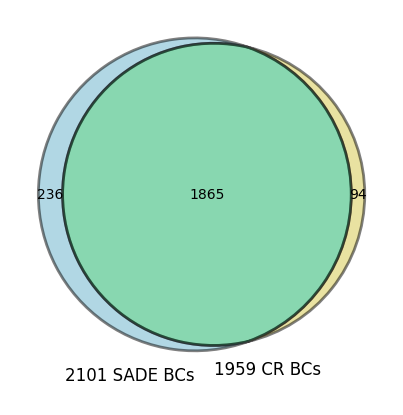

In [13]:
venn_sets = (
    set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_CR']].index),
    )

fig1, ax1 = plt.subplots()

vennfig = venn2(
    venn_sets[:2], 
                set_labels = (f'{len(venn_sets[0])} SADE BCs\n',f'{len(venn_sets[1])} CR BCs\n'), 
                set_colors = ( 'blue', 'orange'), 
                ax = ax1)


set_colors = ("#64B1CB", "#D4C645", "#13B062")  
for idx, color in zip(('10', '01', '11'), set_colors):
    patch = vennfig.get_patch_by_id(idx)
    patch.set_color(color)
    patch.set_alpha(0.5)  # Set transparency for blending
    patch.set_edgecolor('black')  # Set edge color to black
    patch.set_linewidth(2)  # Set edge line width

# plt.title('SADE vs CR', fontsize=16)


In [14]:
union_cell_info.groupby(['atac_pass_CR', 'atac_pass_entropy']).size().unstack(fill_value=0)

atac_pass_entropy,False,True
atac_pass_CR,,
False,189,236
True,94,1865


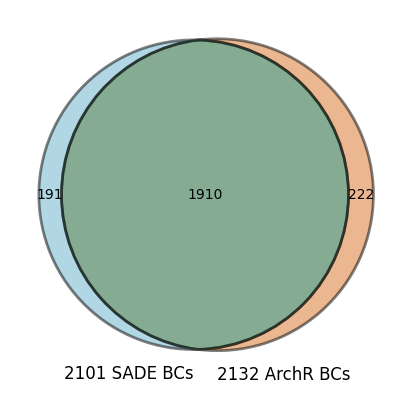

In [15]:
venn_sets = (
    set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_archr_TSS']].index),
    )

set_colors = ('#ADD8E6', '#FFFFE0', '#FFB6C1') 


fig1, ax1 = plt.subplots()

vennfig = venn2(
    venn_sets[:2], 
                set_labels = (f'{len(venn_sets[0])} SADE BCs\n',f'{len(venn_sets[1])} ArchR BCs\n'), 
                ax = ax1)


set_colors = ("#64B1CB", "#D67022", "#0C5B28")  
for idx, color in zip(('10', '01', '11'), set_colors):
    patch = vennfig.get_patch_by_id(idx)
    patch.set_color(color)
    patch.set_alpha(0.5)  # Set transparency for blending
    patch.set_edgecolor('black')  # Set edge color to black
    patch.set_linewidth(2)  # Set edge line width

# plt.title('SADE vs ArchR', fontsize=16)


In [17]:
union_cell_info.groupby(['atac_pass_archr_TSS', 'atac_pass_entropy']).size().unstack(fill_value=0)

atac_pass_entropy,False,True
atac_pass_archr_TSS,,
False,61,191
True,222,1910


In [18]:
total_frag_per_bc = _total_frag_per_bc.copy()
col_list = [     'enough_frag_in_peaks_for_gene_activity']

for col in col_list:
    total_frag_per_bc[col] = total_frag_per_bc.index.map(union_cell_info[col])


col_list = ['atac_pass_entropy', 'atac_pass_CR', 'atac_pass_archr_TSS', ]
for col in col_list:
    total_frag_per_bc[col] = total_frag_per_bc.index.map(union_cell_info[col])
    total_frag_per_bc[col] = total_frag_per_bc[col].fillna(False)


col_list = [            '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST',]
for col in col_list:
    total_frag_per_bc[col] = total_frag_per_bc.index.map(union_cell_info[col])
    total_frag_per_bc[col] = total_frag_per_bc[col].fillna('none')

col_list = ['Entropy', 'DNA_debris']
for col in col_list:
    total_frag_per_bc[col] = total_frag_per_bc.index.map(entropy_df.set_index('atac_bc')[col])




/tmp/ipykernel_4051425/3806003355.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  total_frag_per_bc[col] = total_frag_per_bc[col].fillna(False)
/tmp/ipykernel_4051425/3806003355.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  total_frag_per_bc[col] = total_frag_per_bc[col].fillna(False)
/tmp/ipykernel_4051425/3806003355.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_opt

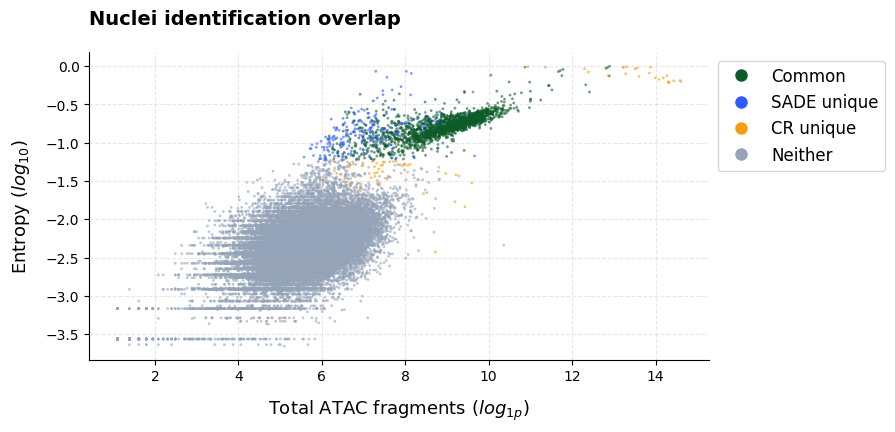

In [ ]:
fig, ax = plt.subplots( figsize=(8, 4) )


colors_map = {'both':'#0C5B28', 'entropy_only':'#2E5BFF', 'cr_only':'#F59E0B', 'none':'#94A3B8'}
labels_map = {'both':'Common', 'entropy_only':'SADE unique', 'cr_only':'CR unique', 'none':'Neither'}
ax.scatter( np.log1p(total_frag_per_bc['total_fragments']), np.log10(total_frag_per_bc['Entropy'] ),  
            c= total_frag_per_bc['_2set_identified_by_atac_SC'].map(colors_map),
            alpha=0.6, 
                s=4,          
                lw=0,         
                rasterized=True # Keeps the file size light if saving to PDF
                        )

# 4. Clean up the Aesthetics
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_xlabel('Total ATAC fragments ($log_{1p}$)', fontsize=13, labelpad=10)
ax.set_ylabel('Entropy ($log_{10}$)', fontsize=13, labelpad=10)
ax.set_title('Nuclei identification overlap', fontsize=14, loc='left', fontweight='bold', pad=20)

handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors_map.items()]
ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label=labels_map[c],
                          markerfacecolor=colors_map[c], markersize=10) for c in colors_map.keys()],
             bbox_to_anchor=(1, 1), loc='upper left', ncol=1, fontsize=12)

plt.show()

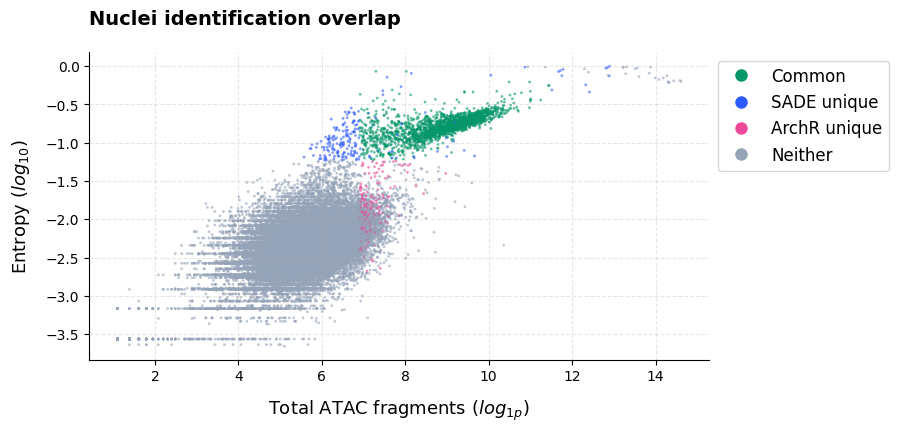

In [35]:
fig, ax = plt.subplots( figsize=(8, 4) )

colors_map = {'both':"#059669", 'entropy_only':'#2E5BFF', 'tss_only':"#EC4899", 'none':'#94A3B8'}
labels_map = {'both':'Common', 'entropy_only':'SADE unique', 'tss_only':'ArchR unique', 'none':'Neither'}
ax.scatter( np.log1p(total_frag_per_bc['total_fragments']), np.log10(total_frag_per_bc['Entropy']),  c= total_frag_per_bc['_2set_identified_by_atac_ST'].map(colors_map), 
            alpha=0.6, 
            s=4,          
            lw=0,         
            rasterized=True # Keeps the file size light if saving to PDF
                )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_xlabel('Total ATAC fragments ($log_{1p}$)', fontsize=13, labelpad=10)
ax.set_ylabel('Entropy ($log_{10}$)', fontsize=13, labelpad=10)
ax.set_title('Nuclei identification overlap', fontsize=14, loc='left', fontweight='bold', pad=20)


handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors_map.items()]

ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label=labels_map[c],
                          markerfacecolor=colors_map[c], markersize=10) for c in colors_map.keys()],
             bbox_to_anchor=(1, 1), loc='upper left', ncol=1, fontsize=12)


plt.show()

## With RNA info

In [83]:
rna_info_file = os.path.join(Union_cell_subdir, 'Union_3set_rna_info.tsv')
union_cell_rna_info = pd.read_csv(rna_info_file, sep='\t', index_col=1)
union_cell_rna_info.head(2)

,rna_barcodes,rna_pass_CR,leiden_RNA_scVI,total_RNA_UMI,total_RNA_UMI_log,n_genes_by_RNA_counts,N_MT_counts,MT%
atac_barcodes,,,,,,,,
ACAGCGGGTTTGTAGC,AAACAGCCAGGCTACT,True,1,3931.0,8.276903,1772,519.0,13.202747
CATTTAGGTAACAGCA,AAACATGCAAGGATTA,True,3,3566.0,8.179481,1689,401.0,11.245092


In [85]:
col_list = ['total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%']
for col in col_list:
    union_cell_info[col] = union_cell_info.index.map(union_cell_rna_info[col])

Text(0, 0.5, 'Total RNA UMI ($log_{1p}$)')

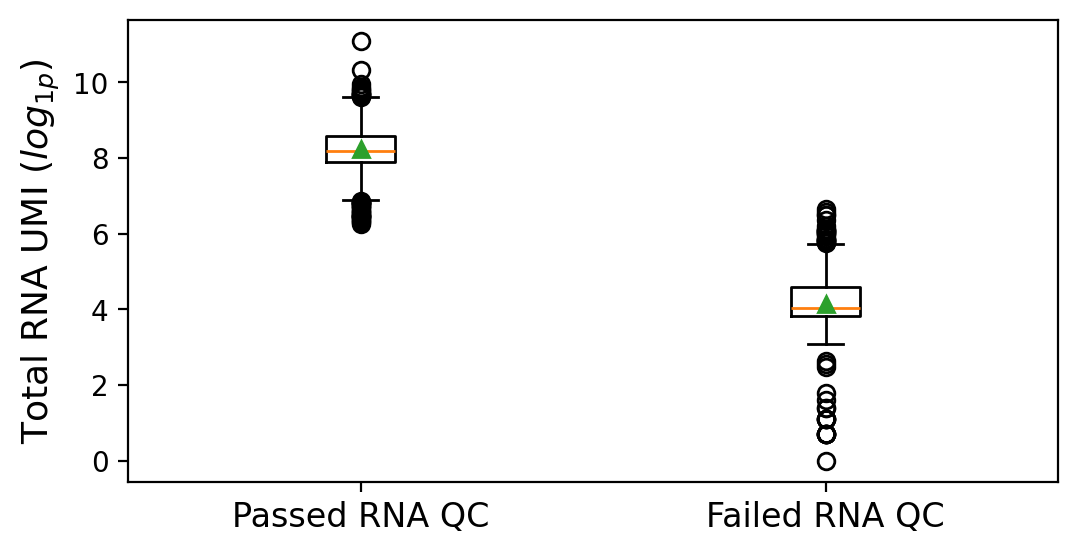

In [96]:
fig, ax = plt.subplots( figsize=(6, 3) )

rna_umi = [union_cell_info.loc[union_cell_info['rna_pass_CR'], 'total_RNA_UMI'],
           union_cell_info.loc[~union_cell_info['rna_pass_CR'], 'total_RNA_UMI'].dropna(),
]
rna_umi = [np.log1p(x) for x in rna_umi]

x_pos = range(len(rna_umi))
ax.boxplot(rna_umi, positions=x_pos, showmeans=True)
ax.set_xticks(x_pos)
ax.set_xticklabels(['Passed RNA QC', 'Failed RNA QC'], fontsize=12)
ax.set_ylabel('Total RNA UMI ($log_{1p}$)', fontsize=13)

In [41]:
union_cell_info.loc[union_cell_info['rna_pass_CR']].groupby('atac_pass_CR').size()

atac_pass_CR
False     153
True     1891
dtype: int64

In [42]:
union_cell_info.loc[union_cell_info['rna_pass_CR']].groupby('atac_pass_entropy').size()

atac_pass_entropy
False      72
True     1972
dtype: int64

In [44]:
union_cell_info.loc[union_cell_info['rna_pass_CR']].groupby('atac_pass_archr_TSS').size()

atac_pass_archr_TSS
False     148
True     1896
dtype: int64

In [48]:
1972 / 2044, 1896 / 2044, 1891 / 2044

(0.9647749510763209, 0.9275929549902152, 0.925146771037182)

In [46]:
union_cell_info['rna_pass_CR'].sum()

np.int64(2044)

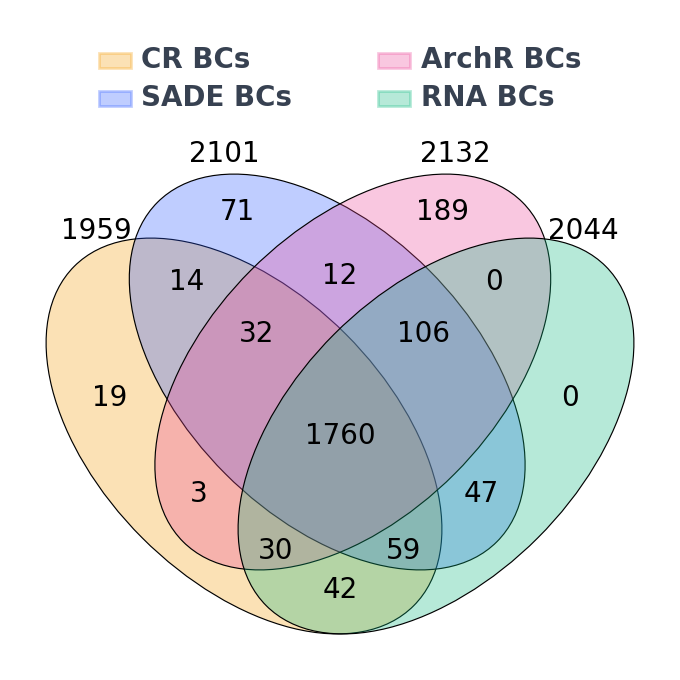

In [ ]:
from venny4py.venny4py import *




venn_4sets = {
    'CR BCs': set(union_cell_info.loc[union_cell_info['atac_pass_CR']].index),
    'SADE BCs':  set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    'ArchR BCs': set(union_cell_info.loc[union_cell_info['atac_pass_archr_TSS']].index),
    'RNA BCs': set(union_cell_info.loc[union_cell_info['rna_pass_CR']].index) }

fig = venny4py(sets=venn_4sets, colors=['#F59E0B', '#2E5BFF', '#EC4899', '#10B981'])
ax = plt.gca()

# Make the circles look soft and premium
for patch in ax.get_children():
    if isinstance(patch, plt.Circle) or 'PathPatch' in str(type(patch)):
        patch.set_alpha(0.6)       # Soften the overlap
        patch.set_edgecolor('white') # White borders make colors "pop"
        patch.set_linewidth(1.5)

# Improve text readability
for text in ax.findobj(plt.Text):
    text.set_fontsize(10)
    # Highlight the set labels (usually the ones with 'BCs')
    if 'BCs' in text.get_text():
        text.set_fontweight('bold')
        text.set_fontsize(10)
        text.set_color('#374151') # Deep charcoal instead of pure black


ax.axis('off')

plt.tight_layout()
plt.show()

### --

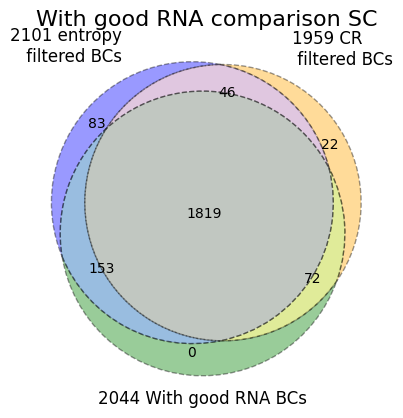

In [27]:

venn_sets = (
    set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_CR']].index),
    set(union_cell_info.loc[union_cell_info['rna_pass_CR']].index)   
)
fixed_sizes = (0.2, 0.2, 0.15, 0.3, 0.2, 0.1, 2) 

# alg = cost_based.LayoutAlgorithm(cost_fn=cost_based.pairwise_cost)
vennfig = venn3(venn_sets, set_labels = (f'{len(venn_sets[0])} entropy\n filtered BCs',f'{len(venn_sets[1])} CR \n filtered BCs', f'{len(venn_sets[2])} With good RNA BCs'), 
                layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=fixed_sizes), 
                set_colors = ( 'blue', 'orange', 'green'))
for id in ['100', '010', '001', '110', '101', '011', '111']:
    vennfig.get_patch_by_id(id).set_edgecolor('black')
    vennfig.get_patch_by_id(id).set_linestyle('dashed')


plt.title('With good RNA comparison SC', fontsize=16)
plt.show()

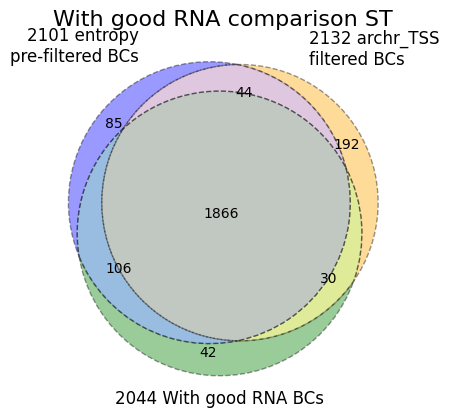

In [17]:

venn_sets = (
    set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_archr_TSS']].index),
    set(union_cell_info.loc[union_cell_info['rna_pass_CR']].index)   
)
fixed_sizes = (0.2, 0.2, 0.15, 0.3, 0.2, 0.1, 2) 

# alg = cost_based.LayoutAlgorithm(cost_fn=cost_based.pairwise_cost)
vennfig = venn3(venn_sets, set_labels = (f'{len(venn_sets[0])} entropy\npre-filtered BCs',f'{len(venn_sets[1])} archr_TSS \nfiltered BCs', f'{len(venn_sets[2])} With good RNA BCs'), 
                layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=fixed_sizes), 
                set_colors = ( 'blue', 'orange', 'green'))
for id in ['100', '010', '001', '110', '101', '011', '111']:
    vennfig.get_patch_by_id(id).set_edgecolor('black')
    vennfig.get_patch_by_id(id).set_linestyle('dashed')


plt.title('With good RNA comparison ST', fontsize=16)
plt.show()

## On 

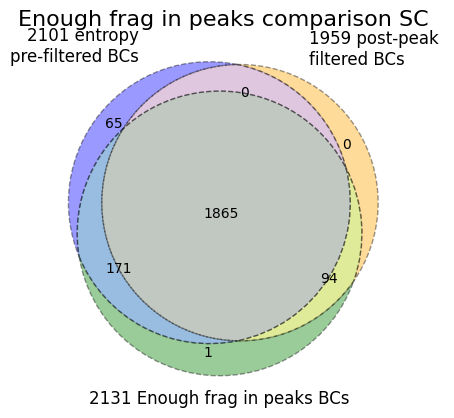

In [11]:
venn_sets = (
    set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_CR']].index),
    set(union_cell_info.loc[union_cell_info['enough_frag_in_peaks_for_gene_activity']].index)   
)
fixed_sizes = (0.2, 0.2, 0.15, 0.3, 0.2, 0.1, 2) 

# alg = cost_based.LayoutAlgorithm(cost_fn=cost_based.pairwise_cost)
vennfig = venn3(venn_sets, set_labels = (f'{len(venn_sets[0])} entropy\npre-filtered BCs',f'{len(venn_sets[1])} post-peak \nfiltered BCs', f'{len(venn_sets[2])} Enough frag in peaks BCs'), 
                layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=fixed_sizes), 
                set_colors = ( 'blue', 'orange', 'green'))
for id in ['100', '010', '001', '110', '101', '011', '111']:
    vennfig.get_patch_by_id(id).set_edgecolor('black')
    vennfig.get_patch_by_id(id).set_linestyle('dashed')


plt.title('Enough frag in peaks comparison SC', fontsize=16)
plt.show()

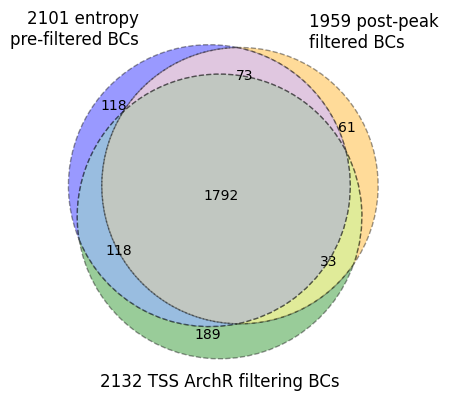

In [12]:


venn_sets = (
    set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_CR']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_archr_TSS']].index)   
)
fixed_sizes = (0.2, 0.2, 0.15, 0.3, 0.2, 0.1, 2) 

# alg = cost_based.LayoutAlgorithm(cost_fn=cost_based.pairwise_cost)
vennfig = venn3(venn_sets, set_labels = (f'{len(venn_sets[0])} entropy\npre-filtered BCs',f'{len(venn_sets[1])} post-peak \nfiltered BCs', f'{len(venn_sets[2])} TSS ArchR filtering BCs'), 
                layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=fixed_sizes), 
                set_colors = ( 'blue', 'orange', 'green'))
for id in ['100', '010', '001', '110', '101', '011', '111']:
    vennfig.get_patch_by_id(id).set_edgecolor('black')
    vennfig.get_patch_by_id(id).set_linestyle('dashed')

plt.show()

In [60]:
total_frag_per_bc.loc[~total_frag_per_bc['Entropy'].isna()]['_2set_identified_by_atac_SC'].value_counts()

_2set_identified_by_atac_SC
none            31105
both             1865
entropy_only      236
cr_only            81
Name: count, dtype: int64

### How many barcoeds have invalid entropy values

In [59]:
total_frag_per_bc['invalid_entropy_value'] = ~total_frag_per_bc.index.isin(entropy_df['atac_bc'])
total_frag_per_bc['invalid_entropy_value'].value_counts()

invalid_entropy_value
True     255722
False     33287
Name: count, dtype: int64

In [60]:
total_frag_per_bc.groupby(['invalid_entropy_value', '_2set_identified_by_atac_SC']).size().unstack(fill_value=0)

_2set_identified_by_atac_SC,both,cr_only,entropy_only,none
invalid_entropy_value,,,,
False,1865,81,236,31105
True,0,13,0,255709


In [2]:
1865 / (1865 + 81)

0.9583761562178829

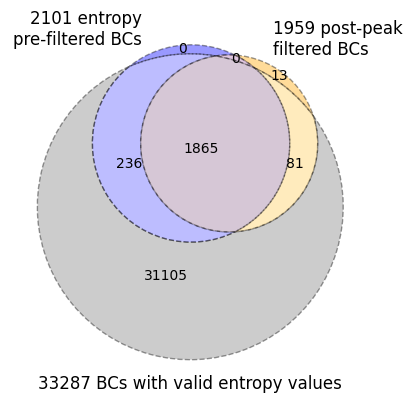

In [61]:
from matplotlib_venn import venn3
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm, cost_based


venn_sets = (
    set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_entropy']].index),
    set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_CR']].index),
    set(total_frag_per_bc.loc[~total_frag_per_bc['invalid_entropy_value']].index)   
)
fixed_sizes = (0.02, 0.02, 0.02, 2, 0.5, 0.2, 1) 

# alg = cost_based.LayoutAlgorithm(cost_fn=cost_based.pairwise_cost)
vennfig = venn3(venn_sets, set_labels = (f'{len(venn_sets[0])} entropy\npre-filtered BCs',f'{len(venn_sets[1])} post-peak \nfiltered BCs', f'{len(venn_sets[2])} BCs with valid entropy values'), 
                layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=fixed_sizes), 
                set_colors = ( 'blue', 'orange', 'grey'))
for id in ['100', '010', '001', '110', '101', '011', '111']:
    vennfig.get_patch_by_id(id).set_edgecolor('black')
    vennfig.get_patch_by_id(id).set_linestyle('dashed')

plt.show()



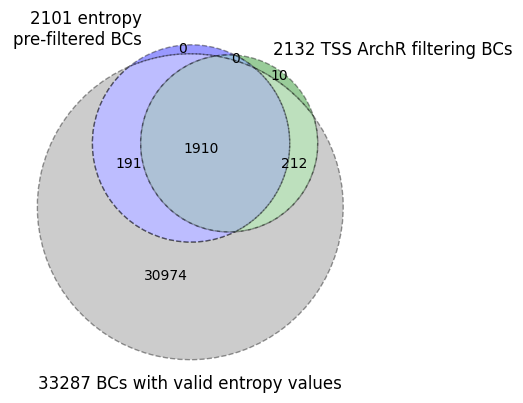

In [62]:


venn_sets = (
    set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_entropy']].index),
    set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_archr_TSS']].index),
    set(total_frag_per_bc.loc[~total_frag_per_bc['invalid_entropy_value']].index)   
)
fixed_sizes = (0.02, 0.02, 0.02, 2, 0.5, 0.2, 1) 

# alg = cost_based.LayoutAlgorithm(cost_fn=cost_based.pairwise_cost)
vennfig = venn3(venn_sets, set_labels = (f'{len(venn_sets[0])} entropy\npre-filtered BCs',f'{len(venn_sets[1])} TSS ArchR filtering BCs', f'{len(venn_sets[2])} BCs with valid entropy values'), 
                layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=fixed_sizes), 
                set_colors = ( 'blue', 'green', 'grey'))
for id in ['100', '010', '001', '110', '101', '011', '111']:
    vennfig.get_patch_by_id(id).set_edgecolor('black')
    vennfig.get_patch_by_id(id).set_linestyle('dashed')

plt.show()

### ---

----- 	 both 	 entropy_only 	 cr_only (invalid entropy) 	 cr_only (valid entropy) 	 none
mean 	 [70.093, 53.756, 25.242, 72.678, 54.672]
median 	 [72.426, 69.779, 1.695, 70.986, 63.244]


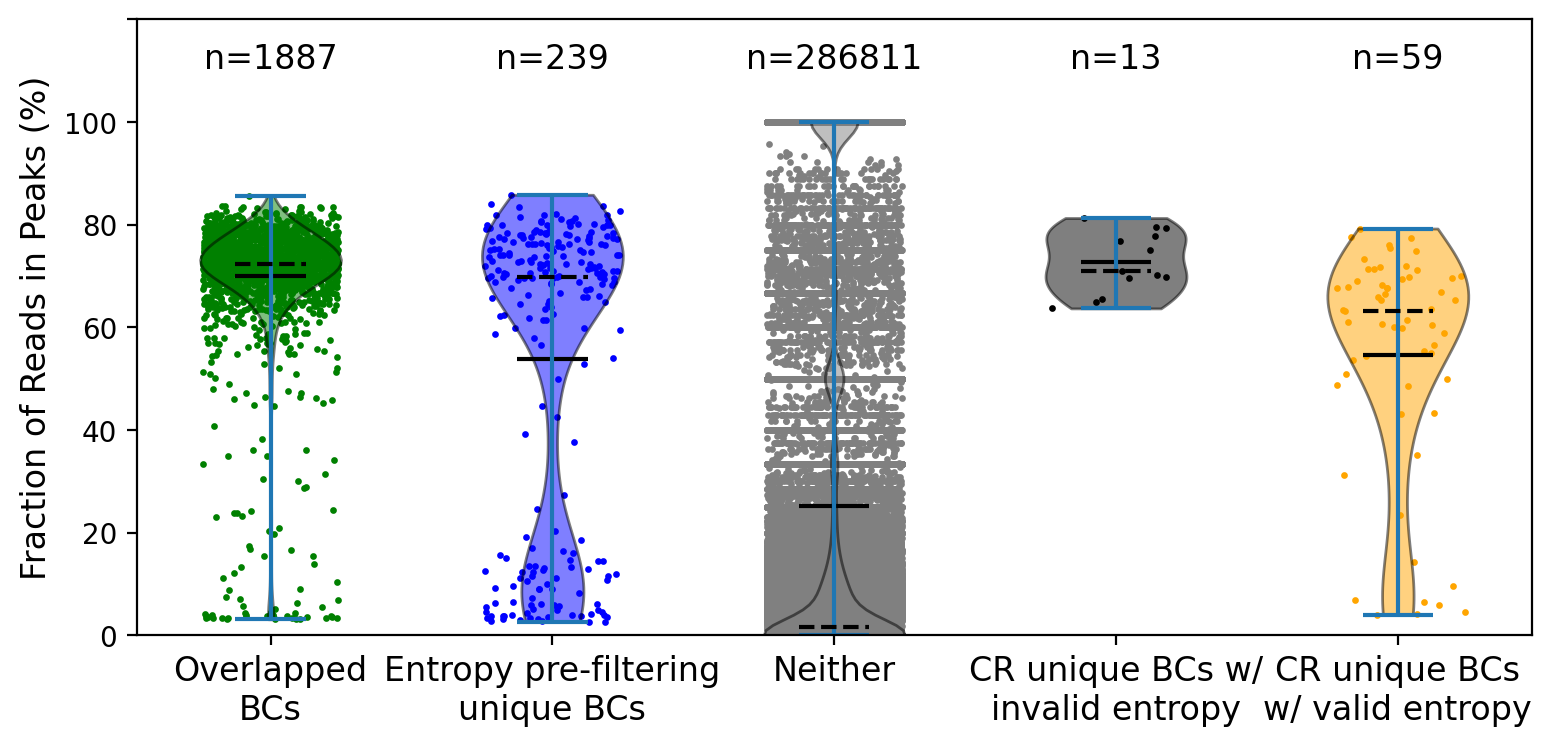

In [34]:
fig, ax = plt.subplots(figsize=(9, 4))



colors_map = ['green', 'blue', 'gray', 'black', 'orange']
frip_values = [ total_frag_per_bc.loc[total_frag_per_bc['_2set_identified_by_atac'] == cat, 'CRpeak_FRIP'].fillna(0) for cat in ['both', 'entropy_only',  'none'] ]
frip_values.append( 
                   total_frag_per_bc.loc[(total_frag_per_bc['_2set_identified_by_atac'] == 'cr_only') & (total_frag_per_bc['invalid_entropy_value']),
                                          'CRpeak_FRIP'] )
frip_values.append(
                   total_frag_per_bc.loc[(total_frag_per_bc['_2set_identified_by_atac'] == 'cr_only') & (~total_frag_per_bc['invalid_entropy_value']),
                                          'CRpeak_FRIP'] )

total_counts = [a.shape[0] for a in frip_values]
mean_frip_values = [np.round(np.mean(a), 3) for a in frip_values]
median_frip_values = [np.round(np.median(a), 3) for a in frip_values]


x_positions = range(len(frip_values))
width = 0.5

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=1, s=2) # s controls point size
    
for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Overlapped\nBCs', 'Entropy pre-filtering\nunique BCs', 'Neither', 
                    'CR unique BCs w/\ninvalid entropy', 'CR unique BCs\nw/ valid entropy'], rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
ax.set_ylim(0, 120)
ax.set_yticks(range(0, 121, 20))
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

# ax.set_title('FRIP in CR Peaks', fontsize=14)

print('----- \t both \t entropy_only \t cr_only (invalid entropy) \t cr_only (valid entropy) \t none')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

# Filter fragments by each category BCs

## Between SADE & CR

In [66]:
bcs = total_frag_per_bc.loc[
    total_frag_per_bc['invalid_entropy_value'] & (total_frag_per_bc['_2set_identified_by_atac_SC'] == 'cr_only')
].index.values
CR_unique_noEntropy_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]

In [55]:
bcs = total_frag_per_bc.loc[
    total_frag_per_bc['identified_by_atac'] == 'cr_only'
].index.values
CR_unique_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]


In [56]:
bcs = total_frag_per_bc.loc[
    (total_frag_per_bc['identified_by_atac'] == 'cr_only' ) &
    (~total_frag_per_bc['invalid_entropy_value'])
].index.values

CR_unique_validEntropy_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]

In [57]:
bcs = total_frag_per_bc.loc[
    total_frag_per_bc['identified_by_atac'] == 'entropy_only'
].index.values
Entropy_unique_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]


In [58]:
bcs = total_frag_per_bc.loc[
    (total_frag_per_bc['identified_by_atac'] == 'both')
].index.values

Overlap_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]

Text(0.5, 1.0, 'CR unique BCs with invalid entropy values')

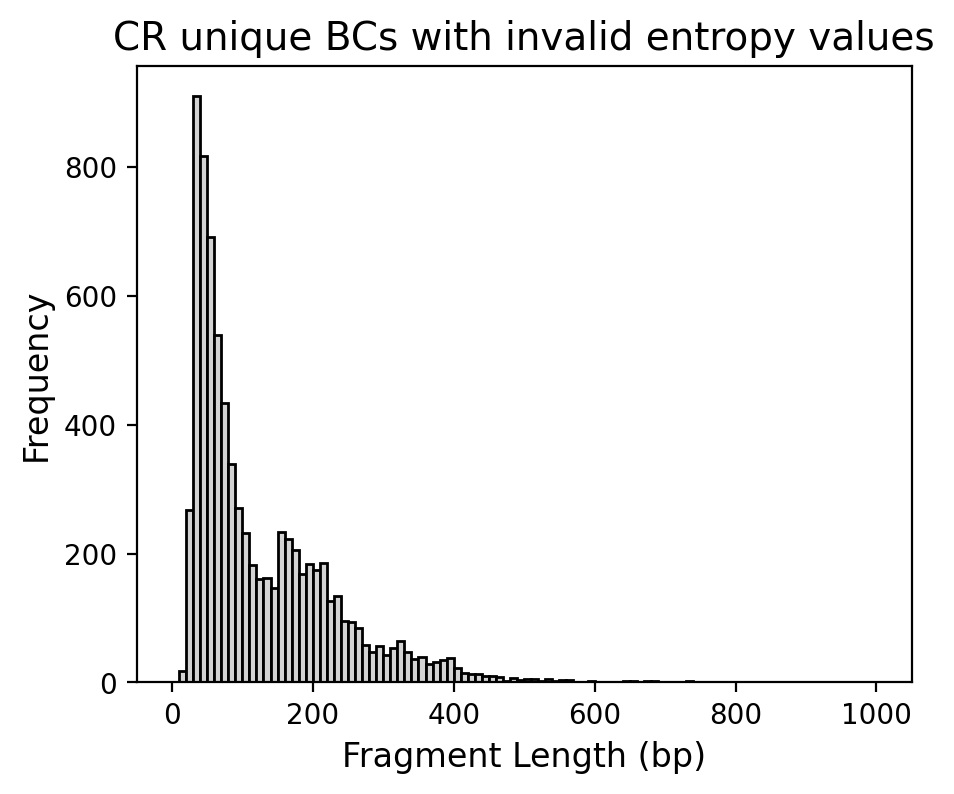

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist( CR_unique_noEntropy_BC_frag['frag_length'], bins=100, range=(0, 1000), color='lightgray', edgecolor='black' )
ax.set_xlabel('Fragment Length (bp)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('CR unique BCs with invalid entropy values', fontsize=14)

## Between SADE & TSS

In [68]:
bcs = total_frag_per_bc.loc[
    total_frag_per_bc['invalid_entropy_value'] & (total_frag_per_bc['_2set_identified_by_atac_ST'] == 'tss_only')
].index.values
TSS_unique_noEntropy_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]

In [63]:
bcs = total_frag_per_bc.loc[
    total_frag_per_bc['_2set_identified_by_atac_ST'] == 'tss_only'
].index.values
TSS_unique_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]

In [64]:
bcs = total_frag_per_bc.loc[
    (total_frag_per_bc['_2set_identified_by_atac_ST'] == 'tss_only' ) &
    (~total_frag_per_bc['invalid_entropy_value'])
].index.values

TSS_unique_validEntropy_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]

Text(0.5, 1.0, 'TSS unique BCs with invalid entropy values')

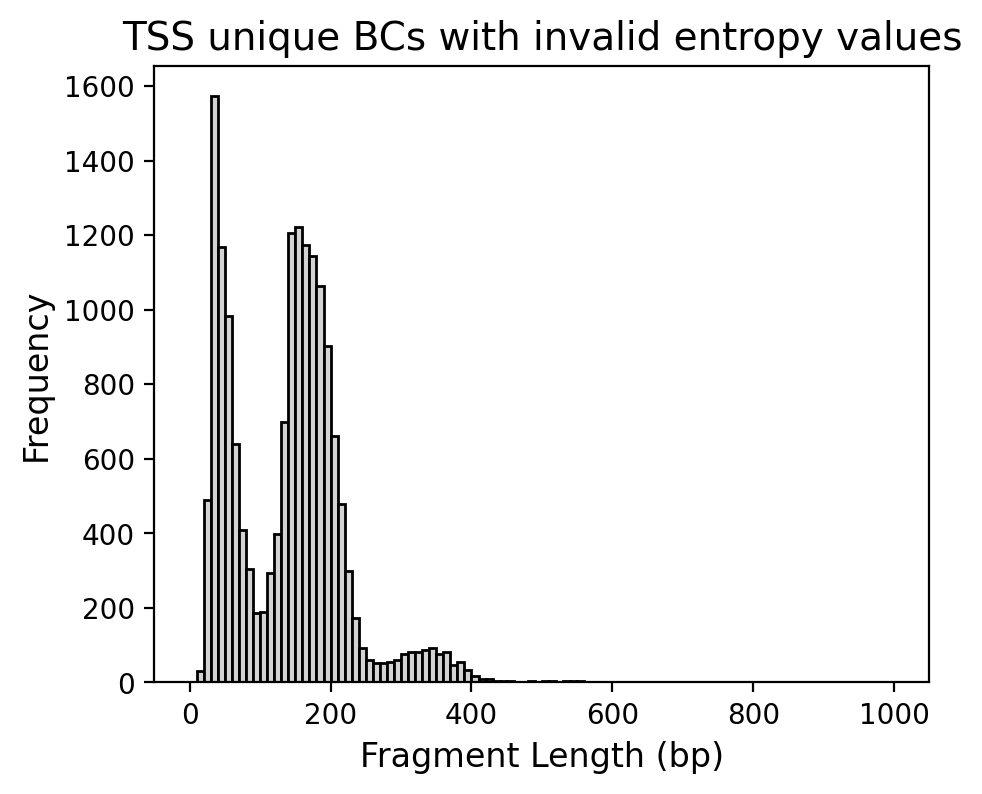

In [69]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist( TSS_unique_noEntropy_BC_frag['frag_length'], bins=100, range=(0, 1000), color='lightgray', edgecolor='black' )
ax.set_xlabel('Fragment Length (bp)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('TSS unique BCs with invalid entropy values', fontsize=14)

# Calculate correlation with chromosome level fragment frequency

In [79]:
CRunique_chrom_counts = CR_unique_validEntropy_BC_frag.groupby(['atac_bc', 'chrom']).size().unstack().fillna(0)
Overlapped_chrom_counts = Overlap_BC_frag.groupby(['atac_bc', 'chrom']).size().unstack().fillna(0)
Entropyunique_chrom_counts = Entropy_unique_BC_frag.groupby(['atac_bc', 'chrom']).size().unstack().fillna(0)

for count in [CRunique_chrom_counts, Overlapped_chrom_counts, Entropyunique_chrom_counts]:
    # drop non-chromosome columns
    columns = [ col for col in count.columns if not col.startswith('chr') ]
    count.drop(columns=columns, inplace=True)

In [80]:
CRunique_BC_corr = pd.DataFrame( index=Overlapped_chrom_counts.index, columns=CRunique_chrom_counts.index )
chrom_names = Overlapped_chrom_counts.columns.values
for bc in CRunique_BC_corr.columns:
    CRunique_BC_corr[bc] = Overlapped_chrom_counts.T.corrwith( CRunique_chrom_counts.loc[bc, chrom_names], axis=0 )

In [81]:
Entropyunique_BC_corr = pd.DataFrame( index=Overlapped_chrom_counts.index, columns=Entropyunique_chrom_counts.index )
chrom_names = Overlapped_chrom_counts.columns.values
for bc in Entropyunique_BC_corr.columns:
    Entropyunique_BC_corr[bc] = Overlapped_chrom_counts.T.corrwith( Entropyunique_chrom_counts.loc[bc, chrom_names], axis=0 )

 ----- 	 CRunique 	 Entropyunique
Mean 	 0.7220 	 0.7977
Median 	 0.8091 	 0.9095


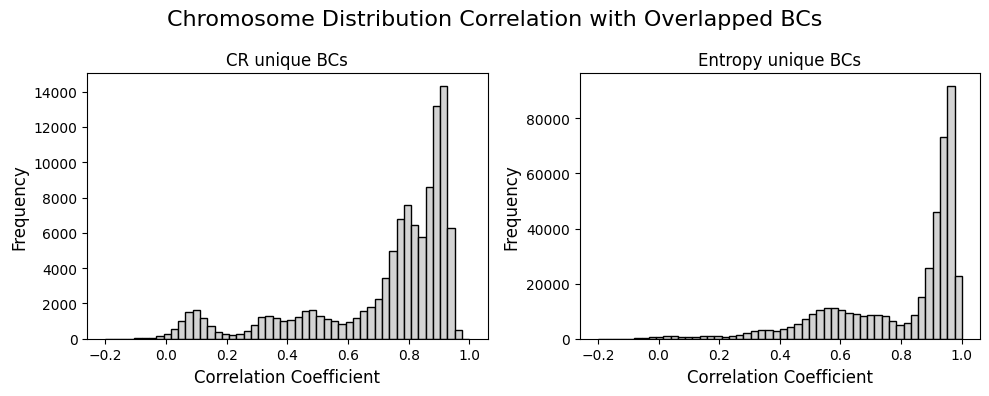

In [101]:
fig, ax = plt.subplots(ncols =2, figsize=(10, 4), sharey=False)

ax[0].hist( CRunique_BC_corr.values.flatten(), bins=50, range=(-0.2, 1.0), color='lightgray', edgecolor='black' )
ax[0].set_xlabel('Correlation Coefficient', fontsize=12)
ax[0].set_ylabel('Frequency', fontsize=12)
ax[0].set_title('CR unique BCs')

ax[1].hist( Entropyunique_BC_corr.values.flatten(), bins=50, range=(-0.2, 1.0), color='lightgray', edgecolor='black' )
ax[1].set_xlabel('Correlation Coefficient', fontsize=12)
ax[1].set_ylabel('Frequency', fontsize=12)
ax[1].set_title('Entropy unique BCs')
fig.suptitle('Chromosome Distribution Correlation with Overlapped BCs', fontsize=16)

fig.tight_layout()

mean_corr_CRunique = np.mean( CRunique_BC_corr.values.flatten() )
mean_corr_Entropyunique = np.mean( Entropyunique_BC_corr.values.flatten() )
median_corr_CRunique = np.median( CRunique_BC_corr.values.flatten() )
median_corr_Entropyunique = np.median( Entropyunique_BC_corr.values.flatten() )

print(f' ----- \t CRunique \t Entropyunique')
print(f'Mean \t {mean_corr_CRunique:.4f} \t {mean_corr_Entropyunique:.4f}')
print(f'Median \t {median_corr_CRunique:.4f} \t {median_corr_Entropyunique:.4f}')

/tmp/ipykernel_14837/3208045024.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax[1].set_xticklabels(chrom_counts.columns, rotation=45)


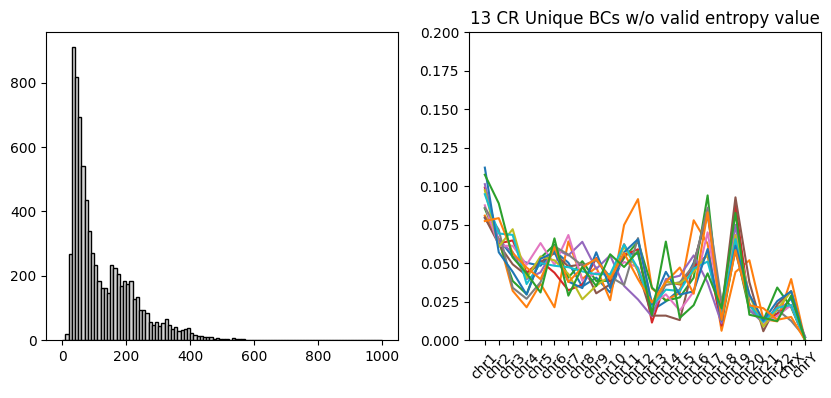

In [85]:
CRunique_noEntropy_chrom_counts = CR_unique_noEntropy_BC_frag.groupby(['atac_bc', 'chrom']).size().unstack().fillna(0)
CRunique_noEntropy_chrom_counts = CRunique_noEntropy_chrom_counts.drop( columns=[ col for col in CRunique_noEntropy_chrom_counts.columns if not col.startswith('chr') ] )

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(10, 4) )

chrom_counts = CRunique_noEntropy_chrom_counts.reindex( sorted(CRunique_noEntropy_chrom_counts.columns, key=lambda x: (int(x[3:]) if x[3:].isdigit() else float('inf')) ), axis=1)

# line plot per barcode 
for idx, row in chrom_counts.iterrows():
    ax[1].plot( chrom_counts.columns, row / row.sum(),  )
ax[1].set_ylim(0, 0.2)
ax[1].set_title(f'{chrom_counts.shape[0]} CR Unique BCs w/o valid entropy value')
_ = ax[1].set_xticklabels(chrom_counts.columns, rotation=45)

_ = ax[0].hist( CR_unique_noEntropy_BC_frag['frag_length'], bins=100, range=(0, 1000), color='lightgray', edgecolor='black' )

## Active autosomes distribution

In [ ]:
chromo_freq_df = frag.loc[frag['atac_bc'].isin(total_frag_per_bc.index)].groupby(['atac_bc', 'chrom']).size().unstack(fill_value=0)


chr_chromo_freq_df = chromo_freq_df[[cname for cname in chromo_freq_df.columns if cname.startswith('chr')]]
nosex_chromo_freq_df = chr_chromo_freq_df[[cname for cname in chr_chromo_freq_df.columns if cname not in ['chrY', 'chrX']]]

a = total_frag_per_bc.join((nosex_chromo_freq_df > 0).sum(axis = 1).to_frame(name='active_number_chroms'), how='left')


fig, ax = plt.subplots(ncols=1, figsize=(10, 4))

x_positions = range(4)
width = 0.9

colors_map = ['green', 'blue', 'orange', 'purple']
frip_values = [ a['active_number_chroms'].loc[ a['_2set_identified_by_atac_ST'] == cat ] for cat in ['both', 'tss_only', 'entropy_only', 'none'] ]
total_counts = [ frip.shape[0] for frip in frip_values ]

mean_frip_values = [np.mean(a) for a in frip_values]
median_frip_values = [np.median(a) for a in frip_values]
# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.3, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['both', 'tss_only', 'entropy_only', 'none'], 
                   rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Number of active non-sex chromosomes', fontsize=12)
ax.set_ylim(19, 25)
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

print('----- \t CR_2ndRound \t ArchR \t entropy_only')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

fig.suptitle('Distribution of Number of active non-sex chromosomes', fontsize=16)